# 원룸 사진 기반 3D 공간 복원 및 평면도 생성  (v2.1)

부동산 매물 사진(다중 뷰)을 입력으로 받아 3D 공간을 복원하고,
가구를 검출/분리하여 평면도를 자동 생성하는 파이프라인.

## 전체 흐름

| 단계 | 작업 | 사용 모델 / 기법 |
|------|------|------------------|
| 0 | 환경 설정 | - |
| 1 | 사진 입력 | gdown |
| 2 | 3D 복원 | DUSt3R |
| 2-1 | 입력 품질 진단 | confidence / 카메라 분산 |
| 3 | 객체 검출 | YOLO11 |
| 4 | 객체 마스크 생성 | SAM2 |
| 5 | 2D 마스크 -> 3D 좌표 연결 | DUSt3R pointmap |
| 6 | 정렬 좌표 생성 (핵심) | 카메라 포즈 기반 정렬 |
| 7 | 3D 모델 저장 (GLB) | trimesh |
| 8 | 바닥 투영 (Top View) | 바닥 평면 정렬 |
| 9 | 평수 기반 검증 | 가구 레퍼런스 스케일 |
| 10 | 평면도 생성 | OpenCV minAreaRect |

> 실행 전 런타임 유형을 GPU로 설정할 것.

---

### 정리본 설계 메모

이전 버전에서 평면도가 깨진 핵심 원인은 **두 개의 좌표계가 섞여 있었기 때문**이다.
GLB 메시는 DUSt3R 내장 정렬(카메라 포즈 기반)을 쓰는데, 평면도/투영은 정렬되지 않은
raw 좌표를 그대로 위에서 눌러서(높이축만 버림) 그렸다. 그래서 바닥이 비스듬히 누운 채로
투영되어 사다리꼴로 찌그러졌다.

이 정리본은 **섹션 6에서 단 하나의 정렬 좌표계를 만들고, 이후 GLB·투영·평수·평면도가
전부 그 좌표를 공유**한다. 정렬되면 바닥이 수평이 되므로 위에서 누르는 단순 투영도
바르게 나온다. 이것이 가장 중요한 변경점이다.


## 0. 환경 설정

In [14]:
import os
import sys
import glob
import shutil
import numpy as np
from PIL import Image

# DUSt3R 저장소 클론 (이미 존재하면 건너뜀)
if not os.path.exists("/content/dust3r"):
    !git clone --recursive https://github.com/naver/dust3r.git /content/dust3r

%cd /content/dust3r
!pip install -q -r requirements.txt
!pip install -q open3d shapely trimesh scipy roma
%cd /content

# DUSt3R 모듈 경로 등록 (중복 방지)
if "/content/dust3r" not in sys.path:
    sys.path.insert(0, "/content/dust3r")

/content/dust3r
/content


In [15]:
# 한글 폰트 설치 및 matplotlib 등록
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

print("한글 폰트 설정 완료")

한글 폰트 설정 완료


## 1. 데이터 다운로드 및 폴더 선택

`TARGET_FOLDER`만 바꾸면 다른 방 사진 세트로 전체 파이프라인이 그대로 돈다.
새 매물을 넣을 때는 `/content/02_Data/` 아래에 폴더를 만들고 사진을 넣은 뒤
폴더명을 `TARGET_FOLDER`에 적으면 된다.

In [16]:
# Google Drive 폴더 다운로드
!gdown --folder 1ivpuKwZ25BosAlM9-YnROKlNPpPk-6Op

print("\n다운로드된 파일 목록")
for root, dirs, files in os.walk("/content/02_Data"):
    for f in files:
        print(" ", os.path.join(root, f))

Retrieving folder contents
Retrieving folder 1k-GNamI93_NOriowcsIvOfSp9GSRegYZ test1
Processing file 1rmq_AYaEFBhAck5jY4b5ZjMl6BI1T_xY 6a2faabef0290_origin.jpg
Processing file 1RslFQoYRD-DifKArz3-_VqDIkbGfO7us 6a2faabf730ea_origin.jpg
Processing file 19UKbayjY5MTRgvOD560XT53nCyHFVsPT 6a2faabfd9ec4_origin.jpg
Retrieving folder 1Vc3jELHuMdiTWyAZG_C1dYF-rgEyrgEP test2
Processing file 1hTKUCsuDIVaoa5FDo7F4cR24LbA1S5OM 1.jpg
Processing file 1U-aDSyb8yVBewj04ZJGDD-en27ZYa8ku 2.jpg
Processing file 1d3hwWNyczH4NpEEUFXWOqs9B2WWVXraq 3.jpg
Processing file 1lf1OnrnRMnuVlKyAsddAv5gm729FyjqL 4.jpg
Retrieving folder 1EwQ3izk-BKU2739p5rTXmRmUM1whDQEk test3
Processing file 1_8LUa0WoOSjqNg3oOyNgBkWly_msN8tE KakaoTalk_20260623_190119914_02.jpg
Processing file 1tK5SJcqd1zAaKSBBbb4BwYxGoDqDYmjV KakaoTalk_20260623_190119914_03.jpg
Processing file 1_ifH74t4m7hSzcjC_Nj9XJXSBCBtfjZr KakaoTalk_20260623_190119914.jpg
Retrieving folder 1rrfNUL18Mfe9UYCewgvBs0IdHghSp-KT test4
Processing file 19bkajJzjn9LQQyHhdPtd

In [17]:
# 처리 대상 폴더 지정
# 선택지: test1 / test2 / test3 / test4 / 직방사진
TARGET_FOLDER = "직방사진"

# 신뢰도 임계값 (DUSt3R confidence 필터링 기준, 포인트클라우드/객체 연결에 공통 사용)
# 주의: 이 값은 섹션 7 메시 export의 min_conf_thr(내장 기준, 기본 3)과는 단위가 다른 별개 값이다.
CONF_THR = 1.0

# 이미지 경로 수집
target_path = f"/content/02_Data/{TARGET_FOLDER}"
img_paths = []
for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
    img_paths.extend(glob.glob(os.path.join(target_path, ext)))
img_paths = sorted(img_paths)

print(f"[{TARGET_FOLDER}] 이미지 {len(img_paths)}장")
for p in img_paths:
    print(" ", os.path.basename(p))

# 이후 단계에서 원본 PIL 이미지가 필요하므로 미리 로드
images_pil = [Image.open(p).convert("RGB") for p in img_paths]

[직방사진] 이미지 5장
  방1.png
  방2.png
  방3.png
  방4.png
  방5.png


## 2. 3D 복원 (DUSt3R)

다중 뷰 사진에서 3D 포인트맵과 카메라 포즈를 복원한다.
모델은 HuggingFace에서 로드하며 `size=512`로 입력을 맞춘다 (1024로 바꾸면 결과가 깨진다).

In [18]:
import torch
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.inference import inference
from dust3r.cloud_opt import global_aligner

# DUSt3R 모델 로드
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AsymmetricCroCo3DStereo.from_pretrained(
    "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
).to(device)
model.eval()
print(f"DUSt3R 모델 로드 완료 (device: {device})")

DUSt3R 모델 로드 완료 (device: cuda)


In [19]:
# 이미지 로드 및 쌍 구성 후 추론
images_dust3r = load_images(img_paths, size=512)
pairs = make_pairs(images_dust3r, scene_graph="complete", prefilter=None, symmetrize=True)
print(f"이미지 쌍 {len(pairs)}개 구성")

with torch.no_grad():
    output = inference(pairs, model, device, batch_size=2)

# Global alignment로 전체 좌표계 정렬
scene = global_aligner(output, device=device)
scene.compute_global_alignment(niter=300, init="mst")
print("3D 복원 및 정렬 완료")

>> Loading a list of 5 images
 - adding /content/02_Data/직방사진/방1.png with resolution 1180x884 --> 512x384
 - adding /content/02_Data/직방사진/방2.png with resolution 1188x890 --> 512x384
 - adding /content/02_Data/직방사진/방3.png with resolution 1178x884 --> 512x384
 - adding /content/02_Data/직방사진/방4.png with resolution 1182x886 --> 512x384
 - adding /content/02_Data/직방사진/방5.png with resolution 1182x890 --> 512x384
 (Found 5 images)
이미지 쌍 20개 구성
>> Inference with model on 20 image pairs


  0%|          | 0/10 [00:00<?, ?it/s]/content/dust3r/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/content/dust3r/dust3r/model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/content/dust3r/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
100%|██████████| 10/10 [00:04<00:00,  2.33it/s]


 init edge (1*,3*) score=np.float64(204.28628540039062)
 init edge (3,4*) score=np.float64(198.2686309814453)
 init edge (2*,1) score=np.float64(159.57301330566406)
 init edge (0*,1) score=np.float64(129.0702362060547)
 init loss = 0.016754167154431343
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


100%|██████████| 300/300 [00:09<00:00, 31.87it/s, lr=1.27413e-06 loss=0.00970822]

3D 복원 및 정렬 완료


## 2-1. 입력 품질 진단

복원이 안 예쁜 이유는 대개 코드가 아니라 **입력 시점 부족**이다.
그걸 코드 탓으로 오해하고 헤매지 않도록 여기서 수치로 가린다.

- **confidence**: 낮으면 DUSt3R가 자신 없다는 뜻 (시점이 안 겹치거나 텍스처 부족).
- **confidence 맵**: 어느 영역이 신뢰 낮은지 (보통 창/단색벽/반사면).
- **카메라 분산**: 카메라가 한곳에 몰리면 baseline이 좁아 복원이 평면적이 된다.

In [20]:
# --- confidence 통계 ---
conf_list = [c.detach().cpu().numpy() for c in scene.get_conf()]

print("=== 뷰별 confidence ===")
for i, c in enumerate(conf_list):
    print(f"  view {i}: mean={c.mean():.2f}  median={np.median(c):.2f}  "
          f"min={c.min():.2f}  max={c.max():.2f}")

overall = np.mean([c.mean() for c in conf_list])
print(f"\n전체 평균 confidence: {overall:.2f}")
if overall < 3.0:
    print(">> 경고: confidence가 낮다. 복원이 부정확할 가능성이 높다.")
    print(">> 시점이 더 겹치는 사진을 쓰거나 장수를 늘리는 게 근본 해결책이다.")
else:
    print(">> confidence 양호.")

=== 뷰별 confidence ===
  view 0: mean=2.31  median=2.45  min=0.00  max=3.36
  view 1: mean=2.72  median=2.80  min=0.00  max=3.48
  view 2: mean=2.64  median=2.74  min=0.07  max=3.26
  view 3: mean=2.61  median=2.80  min=0.00  max=3.33
  view 4: mean=2.57  median=2.65  min=0.43  max=3.09

전체 평균 confidence: 2.57
>> 경고: confidence가 낮다. 복원이 부정확할 가능성이 높다.
>> 시점이 더 겹치는 사진을 쓰거나 장수를 늘리는 게 근본 해결책이다.


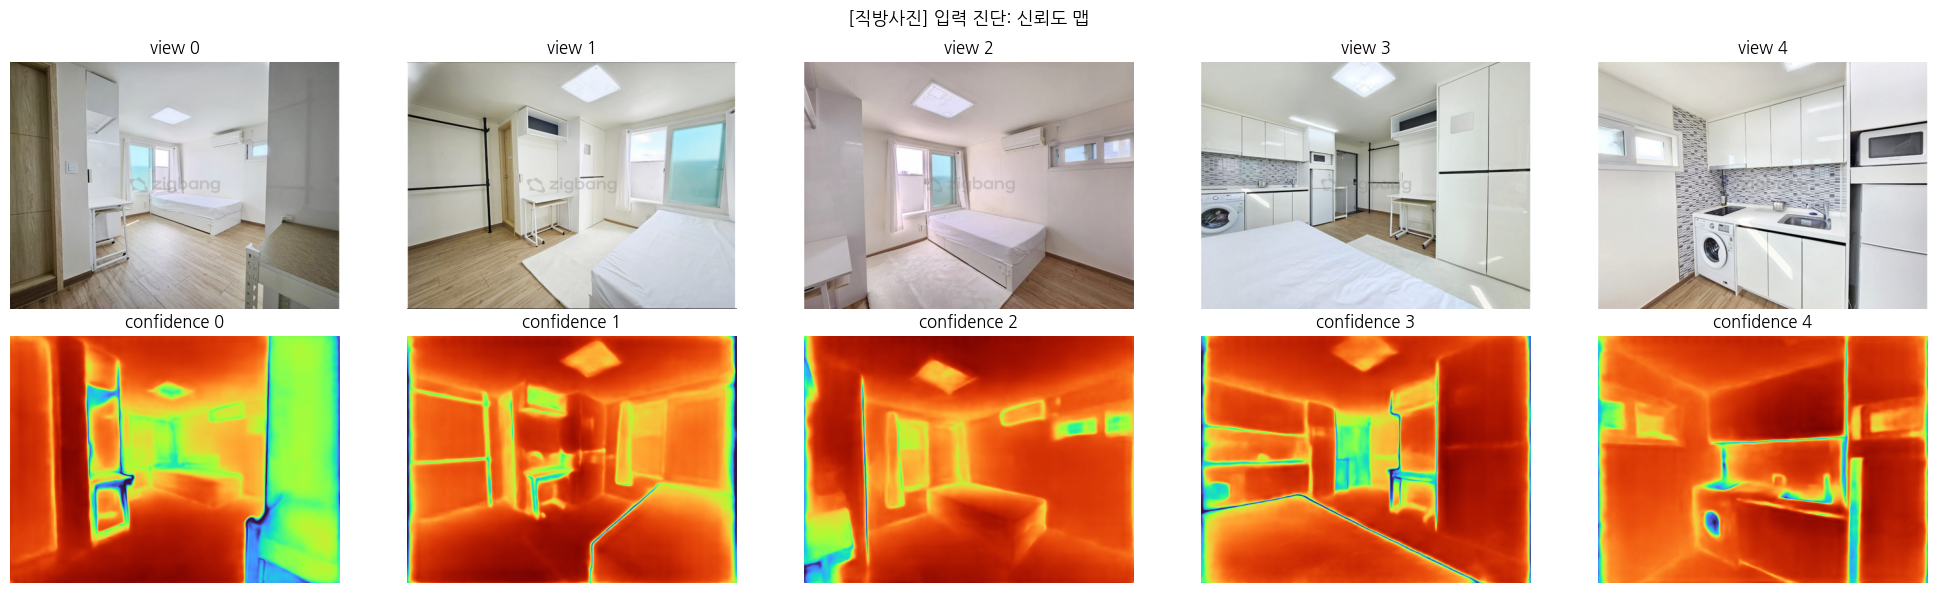

아래쪽: 파란색=신뢰낮음(창/단색벽/반사), 빨간색=신뢰높음


In [21]:
# --- confidence 맵 시각화 ---
imgs_np = scene.imgs   # 정규화된 입력 (H,W,3), 0~1
n = len(imgs_np)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 6))
if n == 1:
    axes = np.array(axes).reshape(2, 1)
for i in range(n):
    axes[0, i].imshow(imgs_np[i]); axes[0, i].set_title(f"view {i}"); axes[0, i].axis("off")
    axes[1, i].imshow(conf_list[i], cmap="turbo")
    axes[1, i].set_title(f"confidence {i}"); axes[1, i].axis("off")
plt.suptitle(f"[{TARGET_FOLDER}] 입력 진단: 신뢰도 맵", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print("아래쪽: 파란색=신뢰낮음(창/단색벽/반사), 빨간색=신뢰높음")

In [22]:
# --- 카메라 포즈 분포 ---
poses = scene.get_im_poses().detach().cpu().numpy()  # (N,4,4) cam2world
cam_centers = poses[:, :3, 3]
print("=== 카메라 위치 (월드 좌표) ===")
for i, cc in enumerate(cam_centers):
    print(f"  cam {i}: [{cc[0]:+.3f}, {cc[1]:+.3f}, {cc[2]:+.3f}]")

if len(cam_centers) > 1:
    spread = np.linalg.norm(cam_centers - cam_centers.mean(0), axis=1).mean()
    print(f"\n카메라 평균 분산(baseline 대략): {spread:.3f}")
    print(">> 너무 작으면 카메라가 한곳에 몰린 것 → 복원이 평면적이 된다.")

=== 카메라 위치 (월드 좌표) ===
  cam 0: [-0.229, -0.000, +0.135]
  cam 1: [+0.000, +0.000, +0.000]
  cam 2: [-0.137, -0.020, +0.126]
  cam 3: [+0.181, +0.008, +0.169]
  cam 4: [-0.025, -0.021, +0.112]

카메라 평균 분산(baseline 대략): 0.132
>> 너무 작으면 카메라가 한곳에 몰린 것 → 복원이 평면적이 된다.


**확인 포인트 — 입력 진단 해석**
- 전체 confidence < 3.0 이고 카메라 분산도 작으면, 이 입력으로는 예쁜 복원이 어렵다.
  **코드를 고치기보다 다른 사진 세트를 시도**하는 게 맞다.
- 특정 뷰만 confidence가 낮으면 그 뷰를 빼고 다시 돌려보는 것도 방법.
- 여기 진단 결과를 포트폴리오 한계 섹션에 그대로 넣으면 설득력이 생긴다.
  (관련 연구 Plane-DUSt3R도 실내 데이터셋이 보통 2~5뷰뿐이라고 지적한다.)

## 3. 객체 검출 (YOLO11)

각 사진에서 가구를 검출한다. `conf` 임계값과 라벨은 매물에 맞게 조정할 수 있다.

In [23]:
!pip install -q ultralytics
from ultralytics import YOLO
import cv2

# YOLO11 large 모델 로드 (가구 검출 정확도 우선)
model_yolo = YOLO("yolo11l.pt")
print("YOLO 모델 로드 완료")

YOLO 모델 로드 완료


In [24]:
# 객체 검출 실행 (conf: 신뢰도 임계값)
results_yolo = []
for path in img_paths:
    result = model_yolo(path, conf=0.3)
    results_yolo.append(result[0])

    print(f"\n{os.path.basename(path)}")
    for box in result[0].boxes:
        cls_name = model_yolo.names[int(box.cls)]
        print(f"  {cls_name} ({float(box.conf):.2f})")


image 1/1 /content/02_Data/직방사진/방1.png: 480x640 1 bed, 1 dining table, 116.3ms
Speed: 2.5ms preprocess, 116.3ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

방1.png
  bed (0.71)
  dining table (0.40)

image 1/1 /content/02_Data/직방사진/방2.png: 480x640 1 bed, 17.4ms
Speed: 2.5ms preprocess, 17.4ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

방2.png
  bed (0.92)

image 1/1 /content/02_Data/직방사진/방3.png: 480x640 1 bed, 17.4ms
Speed: 2.4ms preprocess, 17.4ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

방3.png
  bed (0.64)

image 1/1 /content/02_Data/직방사진/방4.png: 480x640 1 dining table, 1 microwave, 1 sink, 3 refrigerators, 17.2ms
Speed: 2.3ms preprocess, 17.2ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

방4.png
  microwave (0.81)
  refrigerator (0.76)
  refrigerator (0.65)
  refrigerator (0.47)
  dining table (0.35)
  sink (0.30)

image 1/1 /content/02_Data/직방사진/방5.png: 512x640 1 microwave, 1

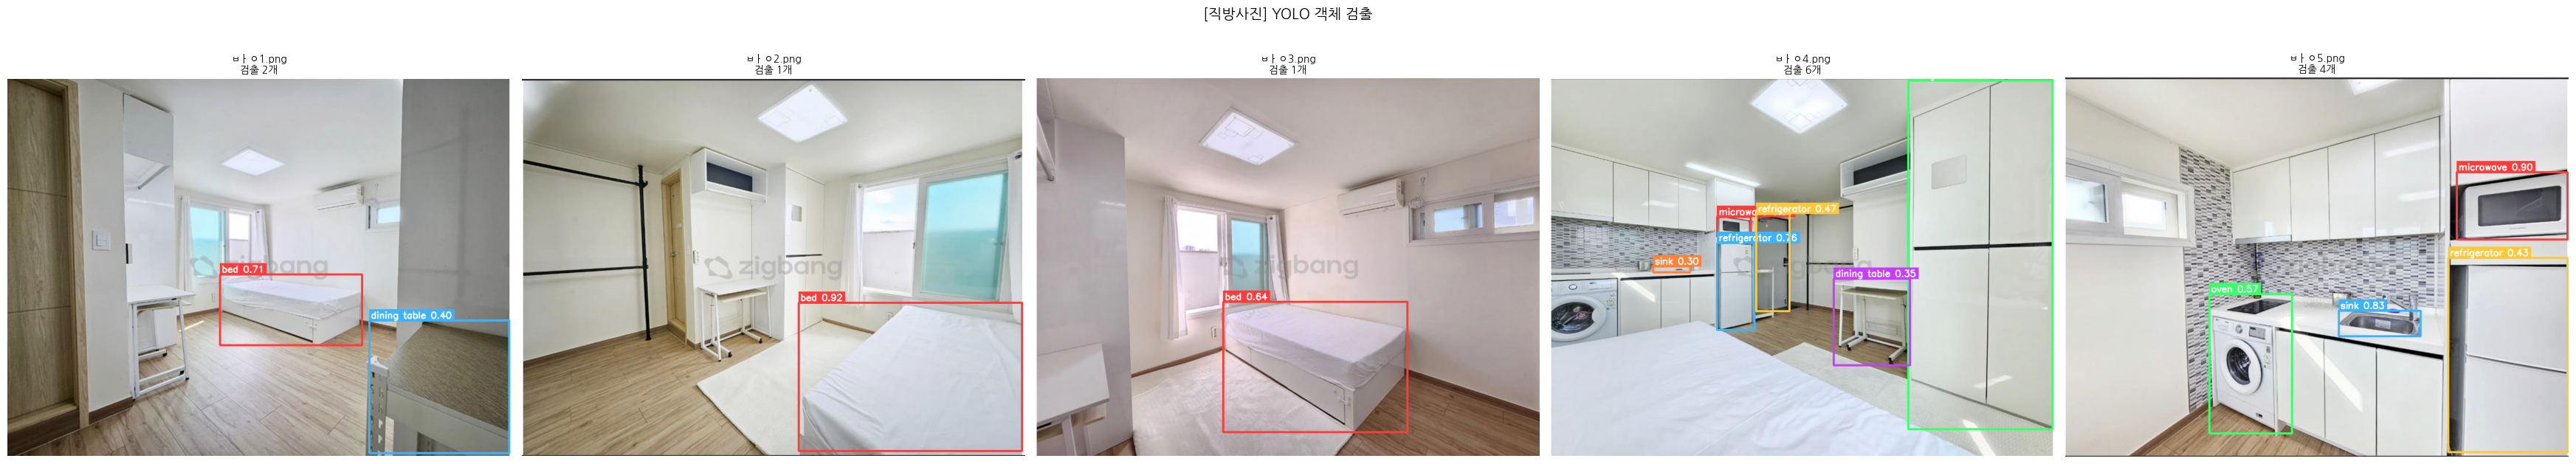

In [25]:
# 검출 결과 시각화 (바운딩 박스 + 라벨)
COLORS = [
    (255, 59, 59), (59, 179, 255), (59, 255, 107),
    (255, 200, 59), (200, 59, 255), (255, 130, 59),
]

n = len(img_paths)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 7))
if n == 1:
    axes = [axes]

for ax, path, result in zip(axes, img_paths, results_yolo):
    img = np.array(Image.open(path).convert("RGB"))

    for i, box in enumerate(result.boxes):
        cls_name = model_yolo.names[int(box.cls)]
        conf = float(box.conf)
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        color = COLORS[i % len(COLORS)]

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
        label = f"{cls_name} {conf:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(img, (x1, y1 - th - 10), (x1 + tw + 8, y1), color, -1)
        cv2.putText(img, label, (x1 + 4, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    ax.imshow(img)
    ax.set_title(f"{os.path.basename(path)}\n검출 {len(result.boxes)}개", fontsize=10)
    ax.axis("off")

plt.suptitle(f"[{TARGET_FOLDER}] YOLO 객체 검출", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"/content/02_Data/{TARGET_FOLDER}_yolo.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. 객체 마스크 생성 (SAM2)

YOLO 박스를 프롬프트로 SAM2가 픽셀 단위 마스크를 만든다.
SAM2 마스크는 float 배열로 나오므로 numpy 인덱스로 쓰기 전에 bool로 캐스팅한다.

In [26]:
!pip install -q sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# SAM2 predictor 로드 (체크포인트 자동 다운로드)
predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2-hiera-large")
print("SAM2 모델 로드 완료")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 15.4 MB/s eta 0:00:00


sam2_hiera_large.pt:   0%|          | 0.00/898M [00:00<?, ?B/s]

SAM2 모델 로드 완료


In [27]:
def get_masks_from_yolo(img_path, yolo_result, predictor):
    """YOLO 박스를 프롬프트로 SAM2 마스크 생성. (이미지, 마스크들, 박스들, 라벨들) 반환"""
    img = np.array(Image.open(img_path).convert("RGB"))

    with torch.inference_mode(), torch.autocast(device, dtype=torch.bfloat16):
        predictor.set_image(img)
        masks_out, boxes_out, labels_out = [], [], []

        for box in yolo_result.boxes:
            cls_name = model_yolo.names[int(box.cls)]
            xyxy = box.xyxy[0].cpu().numpy()
            masks, _, _ = predictor.predict(box=xyxy, multimask_output=False)

            masks_out.append(masks[0])
            boxes_out.append(xyxy)
            labels_out.append(cls_name)

    return img, masks_out, boxes_out, labels_out


# 전체 이미지에 마스크 생성
all_results = []
for path, yolo_result in zip(img_paths, results_yolo):
    img, masks, boxes, labels = get_masks_from_yolo(path, yolo_result, predictor)
    all_results.append({"path": path, "img": img, "masks": masks,
                        "boxes": boxes, "labels": labels})
    print(f"{os.path.basename(path)}: 마스크 {len(masks)}개")

방1.png: 마스크 2개
방2.png: 마스크 1개
방3.png: 마스크 1개
방4.png: 마스크 6개
방5.png: 마스크 4개


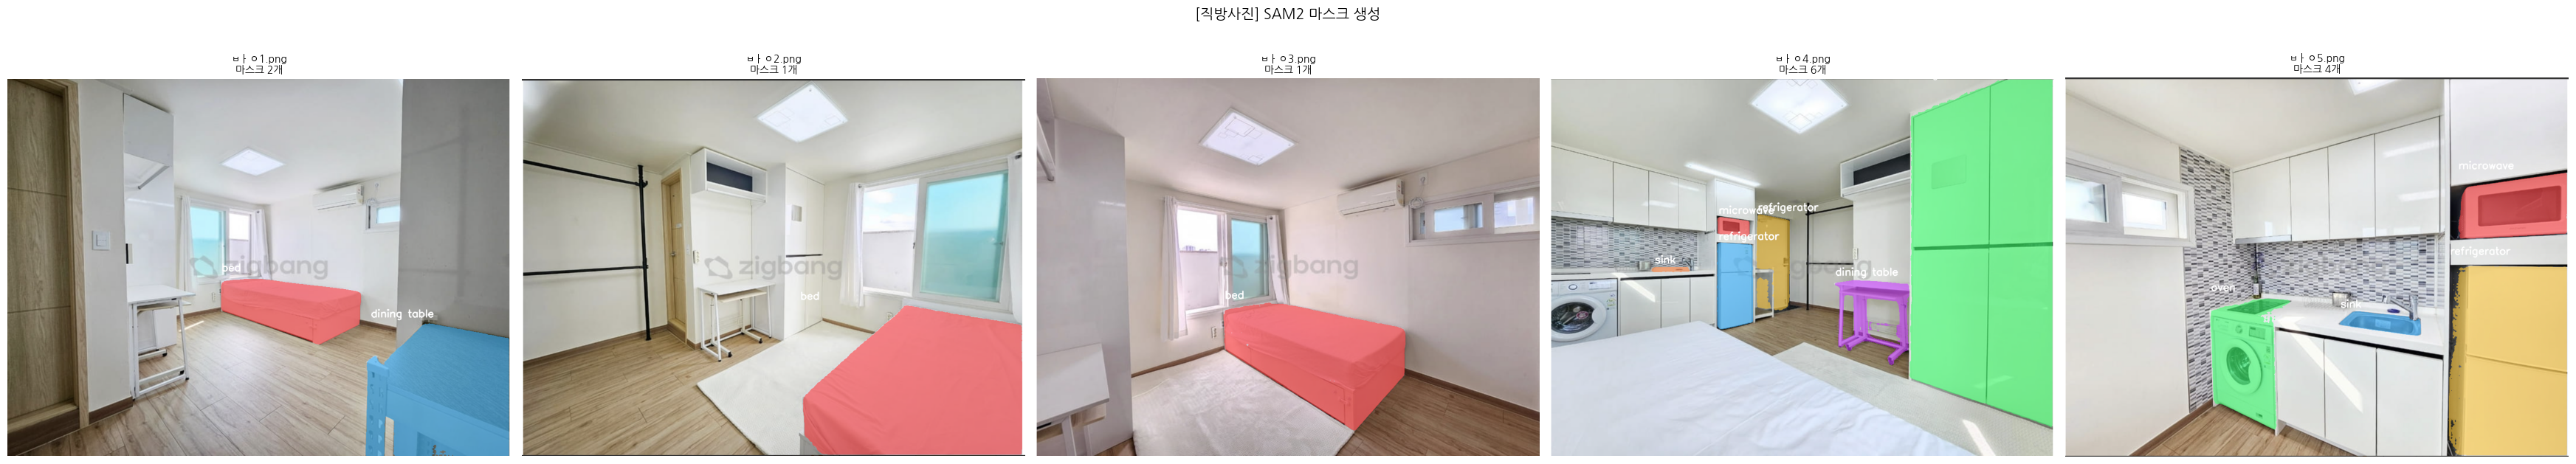

In [28]:
def draw_masks(img, masks, labels):
    """이미지 위에 반투명 마스크 오버레이"""
    overlay = img.copy().astype(np.float32)
    for i, mask in enumerate(masks):
        color = np.array(COLORS[i % len(COLORS)], dtype=np.float32)
        mask_bool = mask.astype(bool)   # float -> bool 변환
        overlay[mask_bool] = overlay[mask_bool] * 0.4 + color * 0.6
    return overlay.astype(np.uint8)


# 마스크 시각화
n = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 7))
if n == 1:
    axes = [axes]

for ax, res in zip(axes, all_results):
    masked_img = draw_masks(res["img"], res["masks"], res["labels"])
    for box, label in zip(res["boxes"], res["labels"]):
        x1, y1 = int(box[0]), int(box[1])
        cv2.putText(masked_img, label, (x1 + 4, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    ax.imshow(masked_img)
    ax.set_title(f"{os.path.basename(res['path'])}\n마스크 {len(res['masks'])}개", fontsize=10)
    ax.axis("off")

plt.suptitle(f"[{TARGET_FOLDER}] SAM2 마스크 생성", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"/content/02_Data/{TARGET_FOLDER}_sam2.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. 2D 마스크 -> 3D 좌표 연결

각 객체 마스크 영역에 해당하는 DUSt3R 포인트맵 좌표를 모은다.
라벨 통합(`LABEL_MERGE`)으로 같은 가구가 다른 라벨로 검출돼도 하나로 합친다
(예: couch로 잡힌 침대를 bed로). 제외 방식 대신 통합 방식을 써서 객체를 잃지 않는다.

In [29]:
from collections import defaultdict
from sklearn.cluster import DBSCAN

# 공간 구조 파악에 의미 있는 큰 가구만 남긴다
TARGET_LABELS = {"bed", "refrigerator", "sink", "tv", "dining table"}
MIN_POINTS = 500


def merge_label(label):
    # 라벨 통합이 필요하면 여기서 매핑한다. 현재는 그대로 사용
    return label


def mask_to_3d(mask, pointmap, conf, conf_thr=CONF_THR):
    """2D 마스크 영역에 해당하는 3D 좌표 추출"""
    pts3d = pointmap.detach().cpu().numpy()
    conf_np = conf.detach().cpu().numpy()
    h, w = pts3d.shape[:2]
    mask_resized = cv2.resize(
        mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST
    ).astype(bool)
    valid = mask_resized & (conf_np > conf_thr)
    return pts3d[valid]


def keep_largest_cluster(pts, eps=0.02, min_samples=30):
    """DBSCAN으로 가장 큰 클러스터만 남겨 줄무늬/이상치를 정리한다.
    eps가 작으면 줄무늬가 잘게 쪼개져 일부만 남고, 크면 효과가 없다. 0.02가 무난."""
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(pts)
    if labels.max() < 0:
        return pts
    largest = np.bincount(labels[labels >= 0]).argmax()
    return pts[labels == largest]


pointmaps = scene.get_pts3d()
confidences = scene.get_conf()

# 라벨별 3D 점 수집 (화이트리스트 + 최소 점 수 필터)
objects_3d = defaultdict(list)
for i, res in enumerate(all_results):
    for j, label in enumerate(res["labels"]):
        label = merge_label(label)
        if label not in TARGET_LABELS:
            continue
        obj_pts = mask_to_3d(res["masks"][j], pointmaps[i], confidences[i])
        if len(obj_pts) < MIN_POINTS:
            continue
        objects_3d[label].append(obj_pts)

objects_3d = {label: np.concatenate(v, axis=0) for label, v in objects_3d.items()}

# 클러스터 정제로 줄무늬/이상치 제거
objects_3d = {label: keep_largest_cluster(pts) for label, pts in objects_3d.items()}

for label, pts in objects_3d.items():
    print(f"{label}: {len(pts):,}개")

bed: 48,931개
dining table: 12,800개
refrigerator: 45,255개
sink: 1,238개


## 6. 정렬 좌표 생성 (핵심)

**이 섹션이 정리본의 핵심이다.** 이전 버전이 평면도에서 깨진 이유는 좌표계가 섞여서였다.
여기서 좌표계를 **하나로 통일**한다.

DUSt3R 좌표는 첫 카메라 기준이라 바닥이 비스듬히 누워 있다. 그대로 위에서 누르면(높이축만 버림)
사다리꼴로 찌그러진다. 그래서:

1. **DUSt3R 내장 변환**으로 raw 좌표를 GLB와 동일한 좌표계로 옮긴다
   (`inv(cams2world[0] @ OPENGL @ rot)`). 이건 GLB 메시가 쓰는 것과 같은 변환이라
   이제 3D·투영·평수·평면도가 전부 같은 좌표를 본다.
2. 그 좌표에서 **RANSAC으로 바닥 평면을 찾아 바닥 법선을 +Y에 정렬**한다.
   정렬이 끝나면 바닥이 수평이 되므로, 이후 X-Z 평면 투영이 바르게 나온다.

`align_points()` 하나로 raw 좌표(N,3)를 정렬 좌표로 바꾸며, 전체 점/객체 점에 똑같이 적용한다.

In [30]:
import trimesh
from scipy.spatial.transform import Rotation

try:
    from dust3r.demo import OPENGL
except ImportError:
    from dust3r.viz import OPENGL

cams2world = scene.get_im_poses().detach().cpu().numpy()
_rot = np.eye(4)
_rot[:3, :3] = Rotation.from_euler("y", np.deg2rad(180)).as_matrix()
GLB_TRANSFORM = np.linalg.inv(cams2world[0] @ OPENGL @ _rot)


def apply_transform(points, T):
    """(N,3) 점에 4x4 변환 적용"""
    pts_h = np.concatenate([points, np.ones((len(points), 1))], axis=1)
    out = (T @ pts_h.T).T
    return out[:, :3]


def find_floor_rotation(points, up_axis=1, n_iter=2000):
    """RANSAC으로 바닥 평면을 검출하고, 그 법선을 +Y축에 맞추는 4x4 회전 행렬 반환"""
    height = points[:, up_axis]
    floor_candidates = points[height <= np.percentile(height, 35)]
    if len(floor_candidates) < 3:
        return np.eye(4), np.array([0.0, 1.0, 0.0])

    diag = np.linalg.norm(points.max(0) - points.min(0))
    threshold = diag * 0.02

    best_inliers, best_normal = -1, np.array([0.0, 1.0, 0.0])
    for _ in range(n_iter):
        idx = np.random.choice(len(floor_candidates), 3, replace=False)
        p1, p2, p3 = floor_candidates[idx]
        normal = np.cross(p2 - p1, p3 - p1)
        nrm = np.linalg.norm(normal)
        if nrm < 1e-6:
            continue
        normal = normal / nrm
        d = -np.dot(normal, p1)
        dist = np.abs(floor_candidates @ normal + d)
        ninl = int((dist < threshold).sum())
        if ninl > best_inliers:
            best_inliers, best_normal = ninl, normal

    if best_normal[up_axis] < 0:
        best_normal = -best_normal

    target = np.array([0.0, 1.0, 0.0])
    v = np.cross(best_normal, target)
    s = np.linalg.norm(v)
    c = float(np.dot(best_normal, target))
    if s < 1e-8:
        R = np.eye(3)
    else:
        vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
        R = np.eye(3) + vx + vx @ vx * ((1 - c) / (s * s))

    T = np.eye(4)
    T[:3, :3] = R
    return T, best_normal


_all_pts_raw, _all_cols = [], []
for i, pts in enumerate(pointmaps):
    pts_np = pts.detach().cpu().numpy().reshape(-1, 3)
    conf_np = confidences[i].detach().cpu().numpy().flatten()
    mask = conf_np > CONF_THR
    h, w = pts.shape[:2]
    img_resized = np.array(images_pil[i].resize((w, h))).reshape(-1, 3)
    _all_pts_raw.append(pts_np[mask])
    _all_cols.append(img_resized[mask])
_all_pts_raw = np.concatenate(_all_pts_raw, axis=0)
all_cols = np.concatenate(_all_cols, axis=0) / 255.0

_all_pts_glb = apply_transform(_all_pts_raw, GLB_TRANSFORM)
FLOOR_ROT, floor_normal = find_floor_rotation(_all_pts_glb)
print(f"검출된 바닥 법선(GLB좌표): [{floor_normal[0]:+.2f}, {floor_normal[1]:+.2f}, {floor_normal[2]:+.2f}]")

ALIGN_TRANSFORM = FLOOR_ROT @ GLB_TRANSFORM


def align_points(points_raw):
    """raw DUSt3R 좌표(N,3) -> 정렬 좌표(N,3). 바닥이 수평, +Y가 위."""
    return apply_transform(points_raw, ALIGN_TRANSFORM)


all_pts = align_points(_all_pts_raw)
objects_3d_aligned = {label: align_points(pts)
                      for label, pts in objects_3d.items()}

print(f"\n정렬 완료. 전체 포인트 수: {len(all_pts):,}")
print("이제 all_pts / objects_3d_aligned 는 바닥이 수평으로 정렬된 좌표다.")
print("높이축은 Y(=1). 위에서 내려다보는 투영은 X-Z 평면을 쓰면 된다.")

검출된 바닥 법선(GLB좌표): [+0.18, +0.96, -0.23]

정렬 완료. 전체 포인트 수: 960,596
이제 all_pts / objects_3d_aligned 는 바닥이 수평으로 정렬된 좌표다.
높이축은 Y(=1). 위에서 내려다보는 투영은 X-Z 평면을 쓰면 된다.


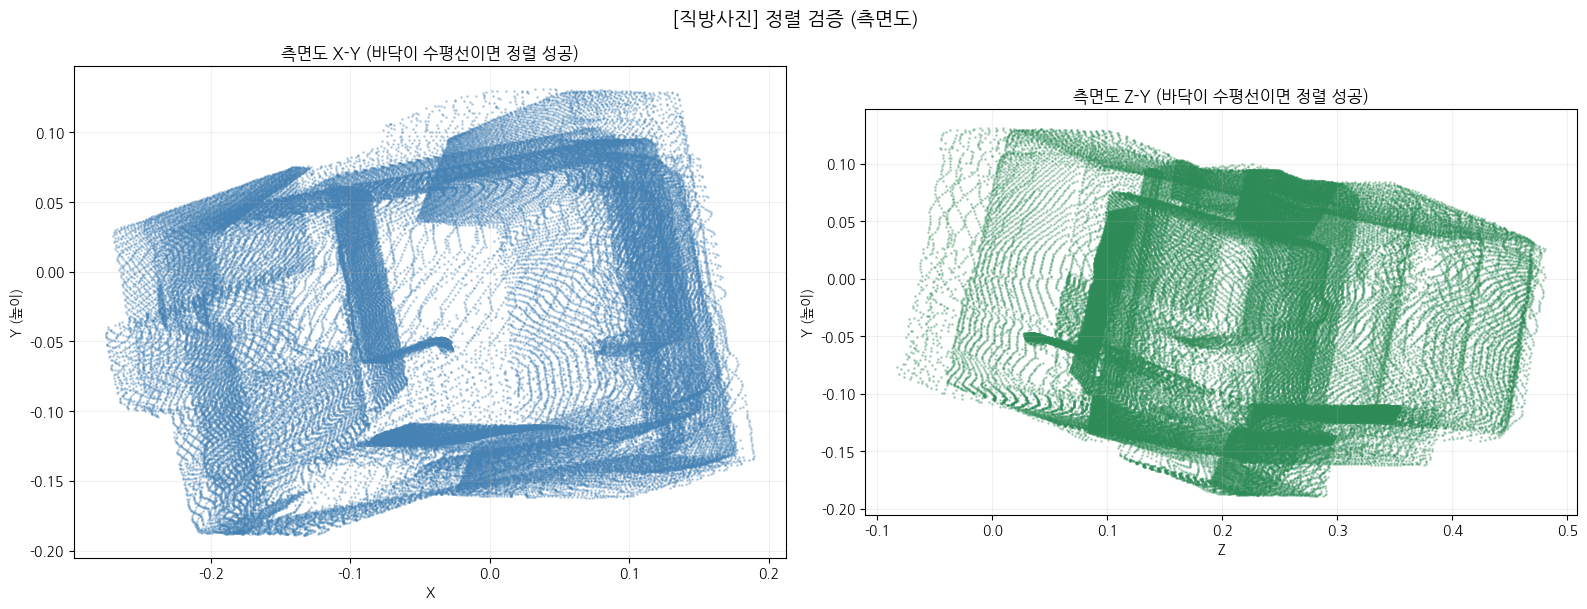

>> 두 측면도에서 바닥이 비스듬하지 않고 수평으로 깔리면 정렬 성공.
>> 여전히 비스듬하면 바닥 후보 비율(percentile 35)이나 입력 품질을 점검.


In [31]:
# 정렬 검증: 바닥이 정말 수평이 됐는지 측면도로 확인
# 정렬이 잘 됐으면 바닥 점들의 Y값이 좁은 띠에 모이고, 벽은 수직으로 선다.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 측면도 (X-Y): 바닥이 수평선으로 보여야 정상
axes[0].scatter(all_pts[::10, 0], all_pts[::10, 1], c="steelblue", s=1, alpha=0.3)
axes[0].set_title("측면도 X-Y (바닥이 수평선이면 정렬 성공)", fontweight="bold")
axes[0].set_xlabel("X"); axes[0].set_ylabel("Y (높이)")
axes[0].set_aspect("equal"); axes[0].grid(True, alpha=0.2)

# 또 다른 측면도 (Z-Y)
axes[1].scatter(all_pts[::10, 2], all_pts[::10, 1], c="seagreen", s=1, alpha=0.3)
axes[1].set_title("측면도 Z-Y (바닥이 수평선이면 정렬 성공)", fontweight="bold")
axes[1].set_xlabel("Z"); axes[1].set_ylabel("Y (높이)")
axes[1].set_aspect("equal"); axes[1].grid(True, alpha=0.2)

plt.suptitle(f"[{TARGET_FOLDER}] 정렬 검증 (측면도)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()
print(">> 두 측면도에서 바닥이 비스듬하지 않고 수평으로 깔리면 정렬 성공.")
print(">> 여전히 비스듬하면 바닥 후보 비율(percentile 35)이나 입력 품질을 점검.")

## 7. 3D 모델 저장 (GLB)

복원 결과를 GLB로 저장한다. 두 가지를 만든다.

- **포인트클라우드 GLB**: 정렬된 전체 점 + 객체별 라벨색. 희소 시점에서 가장 안정적인 표현.
- **텍스처 메시 GLB**: DUSt3R 내장 헬퍼(`pts3d_to_trimesh` + `cat_meshes`)로 방 메시를 만들고
  객체 메시를 얹는다. 메시는 반드시 내장 기준 `min_conf_thr=3`을 쓴다
  (포인트클라우드용 `CONF_THR=1.0`과는 단위가 다른 별개 값).

한글 파일명은 `files.download`가 멈추므로 영문 파일명으로 저장/다운로드한다.

In [32]:
import open3d as o3d
from google.colab import files

# 라벨별 고정 색상 (어느 이미지에서 검출되든 같은 색 유지)
LABEL_COLORS = {
    "bed":          [255, 59, 59],    # 빨강
    "refrigerator": [59, 255, 107],   # 초록
    "sink":         [59, 179, 255],   # 파랑
    "dining table": [255, 59, 180],   # 핑크
    "tv":           [150, 150, 255],  # 연보라
}
DEFAULT_COLOR = [180, 180, 180]   # 매핑 없는 객체는 회색

# 영문 파일명 (한글명은 다운로드가 멈춤). 폴더명이 한글이어도 출력은 영문으로 고정.
SAFE_NAME = "room"


def clean_pointcloud(points, colors=None, n_neighbors=20, std_ratio=2.0):
    """통계적 이상치 제거"""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    if colors is not None:
        pcd.colors = o3d.utility.Vector3dVector(colors)
    clean, _ = pcd.remove_statistical_outlier(n_neighbors, std_ratio)
    pts = np.asarray(clean.points)
    cols = np.asarray(clean.colors) if colors is not None else None
    return pts, cols

print("GLB 색상/헬퍼 준비 완료")

GLB 색상/헬퍼 준비 완료


In [33]:
# --- 포인트클라우드 GLB (정렬 좌표 사용) ---
# all_pts / objects_3d_aligned 는 이미 정렬돼 있으므로 추가 좌표 변환이 필요 없다.
def save_pointcloud_glb(target_name, clean_depth=True):
    scene_export = trimesh.Scene()

    room_pts, room_cols = all_pts, all_cols
    if clean_depth:
        room_pts, room_cols = clean_pointcloud(room_pts, room_cols)
    full_pcd = trimesh.PointCloud(
        vertices=room_pts,
        colors=(room_cols * 255).astype(np.uint8),
    )
    scene_export.add_geometry(full_pcd, geom_name="room")

    for label, pts in objects_3d_aligned.items():
        color = LABEL_COLORS.get(label, DEFAULT_COLOR)
        obj_pts = pts
        if clean_depth:
            obj_pts, _ = clean_pointcloud(obj_pts, n_neighbors=10)
        colors = np.tile(color, (len(obj_pts), 1)).astype(np.uint8)
        geom = trimesh.PointCloud(vertices=obj_pts, colors=colors)
        scene_export.add_geometry(geom, geom_name=label)
        print(f"  {label}: {len(obj_pts):,}개")

    glb_path = f"/content/{target_name}_pointcloud.glb"
    scene_export.export(glb_path)
    print("저장 완료:", glb_path)
    return glb_path


pcd_glb = save_pointcloud_glb(SAFE_NAME, clean_depth=True)
files.download(pcd_glb)

  bed: 46,827개
  dining table: 12,266개
  refrigerator: 44,277개
  sink: 1,195개
저장 완료: /content/room_pointcloud.glb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
# --- 텍스처 메시 GLB (DUSt3R 내장 헬퍼 사용) ---
from dust3r.demo import pts3d_to_trimesh, cat_meshes
from dust3r.utils.device import to_numpy


def save_mesh_glb(scene, all_results, target_name,
                  min_conf_thr=3, clean_depth=True):
    """방 텍스처 메시 위에 객체 라벨색 메시를 얹어 GLB로 저장.

    좌표 정렬은 섹션 6의 ALIGN_TRANSFORM과 동일하게 맞춘다
    (= 내장 GLB 변환 @ 바닥회전). 그래야 포인트클라우드/평면도와 좌표가 일치한다.
    min_conf_thr : 내장 함수 기준 신뢰도 임계값(기본 3). CONF_THR(1.0)과 단위가 다름.
    """
    if clean_depth:
        scene = scene.clean_pointcloud()

    rgbimg = scene.imgs
    pts3d = to_numpy(scene.get_pts3d())
    scene.min_conf_thr = float(scene.conf_trf(torch.tensor(min_conf_thr)))
    msk = to_numpy(scene.get_masks())

    out = trimesh.Scene()

    # 방 전체 텍스처 메시
    room_meshes = [pts3d_to_trimesh(rgbimg[i], pts3d[i], msk[i]) for i in range(len(rgbimg))]
    room_mesh = trimesh.Trimesh(**cat_meshes(room_meshes))
    out.add_geometry(room_mesh)

    # 객체 라벨색 메시
    for i, res in enumerate(all_results):
        H, W = pts3d[i].shape[:2]
        for j, label in enumerate(res["labels"]):
            label = merge_label(label)
            color = LABEL_COLORS.get(label, DEFAULT_COLOR)
            obj_mask = cv2.resize(res["masks"][j].astype(np.uint8), (W, H),
                                  interpolation=cv2.INTER_NEAREST).astype(bool)
            valid = obj_mask & msk[i]
            if valid.sum() < 3:
                continue
            solid = np.zeros((H, W, 3), dtype=np.float32)
            solid[:] = np.array(color) / 255.0
            md_ = pts3d_to_trimesh(solid, pts3d[i], valid)
            if len(md_["faces"]) == 0:
                continue
            out.add_geometry(trimesh.Trimesh(**md_), geom_name=f"{label}_{i}_{j}")

    # 좌표 정렬: 섹션 6 ALIGN_TRANSFORM 그대로 적용 (포인트클라우드/평면도와 일치)
    out.apply_transform(ALIGN_TRANSFORM)

    glb_path = f"/content/{target_name}_mesh.glb"
    out.export(glb_path)
    print("저장 완료:", glb_path)
    return glb_path


mesh_glb = save_mesh_glb(scene, all_results, SAFE_NAME, min_conf_thr=3, clean_depth=True)
files.download(mesh_glb)

저장 완료: /content/room_mesh.glb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. 바닥 투영 (Top View)

정렬이 끝났으므로 투영은 단순하다. **높이축 Y를 버리고 X-Z 평면만** 보면 그게 위에서
내려다본 모습이다. 섹션 6에서 바닥을 수평으로 맞췄기 때문에 더 이상 찌그러지지 않는다.

(이전 버전은 정렬 없이 raw 좌표를 그대로 눌러서 사다리꼴로 깨졌다. 그 단계를 섹션 6으로
앞당겨 해결했으므로 여기서는 단순 투영만 하면 된다.)

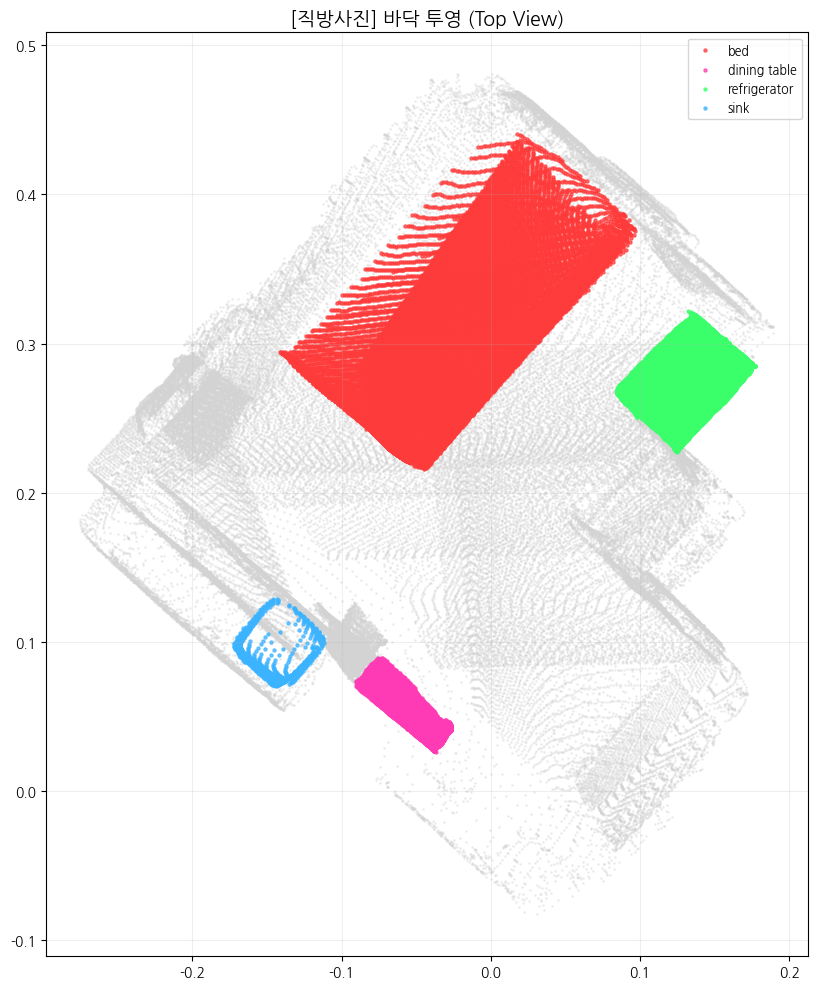

>> 방 외곽이 직사각형에 가깝게 보이면 정렬·투영이 제대로 된 것이다.


In [35]:
def top_view(points):
    """정렬된 좌표(N,3)를 위에서 내려다본 2D(X,Z)로 투영"""
    return points[:, [0, 2]]   # Y(높이) 버림


# 전체 + 객체 투영
room_2d = top_view(all_pts)
objects_2d = {label: top_view(pts) for label, pts in objects_3d_aligned.items()}

# 시각화
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(room_2d[::10, 0], room_2d[::10, 1], c="lightgray", s=1, alpha=0.3)
for label, obj_2d in objects_2d.items():
    color = np.array(LABEL_COLORS.get(label, DEFAULT_COLOR)) / 255
    ax.scatter(obj_2d[:, 0], obj_2d[:, 1], c=[color], s=5, alpha=0.7, label=label)

ax.set_title(f"[{TARGET_FOLDER}] 바닥 투영 (Top View)", fontsize=14, fontweight="bold")
ax.set_aspect("equal")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f"/content/02_Data/{TARGET_FOLDER}_topview.png", dpi=150, bbox_inches="tight")
plt.show()
print(">> 방 외곽이 직사각형에 가깝게 보이면 정렬·투영이 제대로 된 것이다.")

## 9. 평수 기반 검증 (정량 평가 지표)

DUSt3R 출력은 스케일이 임의(실제 미터 아님)다. 가구의 실제 표준 크기로 스케일 계수를
추정해 보정한 뒤 바닥 면적을 평수로 환산한다. 추정 평수를 직방/다방의 실제 평수와 비교하는 게
**이 프로젝트의 핵심 정량 지표**다.

스케일은 가구 표준 크기(이상치 제거 후 가중 중앙값)를 1차로, 천장고를 fallback 기준으로 쓴다.
두 방법이 비슷하게 수렴하면 좋은 신호다. (Depth Anything의 metric depth는 DUSt3R 상대좌표와
단위가 안 맞아 폐기했다.)

In [36]:
from scipy.spatial import ConvexHull

CEILING_CANDIDATES = [2.3, 2.4]   # 한국 주거 천장고 표준
UP_AXIS = 1

up = all_pts[:, UP_AXIS]

# 1) 천장고 = Y 히스토그램 바닥/천장 봉우리 간격 (min-max는 노이즈로 과대평가)
hist, edges = np.histogram(up, bins=80)
centers = (edges[:-1] + edges[1:]) / 2
n = len(centers)
floor_peak = centers[:int(n*0.35)][np.argmax(hist[:int(n*0.35)])]
ceil_peak  = centers[int(n*0.65):][np.argmax(hist[int(n*0.65):])]
ceiling_raw = ceil_peak - floor_peak

print(f"바닥 봉우리 Y = {floor_peak:.4f}")
print(f"천장 봉우리 Y = {ceil_peak:.4f}")
print(f"천장고(raw 봉우리 간격) = {ceiling_raw:.4f}")
print(f"(참고) 단순 min-max = {up.max()-up.min():.4f}  <- 노이즈로 과대평가")

# 2) 바닥 띠만 추출 -> X-Z convex hull 면적 (가구 줄무늬/회전과 무관)
band = (up > floor_peak - 0.02) & (up < floor_peak + 0.08)
floor_pts = all_pts[band][:, [0, 2]]
print(f"\n바닥 띠 점 개수: {len(floor_pts)}")

results = []
for ceil_m in CEILING_CANDIDATES:
    scale = ceil_m / ceiling_raw
    hull = ConvexHull(floor_pts)
    area_m2 = hull.volume * scale * scale   # 2D hull.volume = 면적
    pyeong = area_m2 / 3.305785
    results.append((ceil_m, scale, area_m2, pyeong))
    print(f"[천장고 {ceil_m}m] scale={scale:.3f}  면적={area_m2:.2f} m^2  (~{pyeong:.1f}평)")

# 평면도(섹션 10)가 쓰는 SCALE: 2.3m 기준
SCALE = results[0][1]
print(f"\n>> SCALE = {SCALE:.4f} (천장고 {CEILING_CANDIDATES[0]}m 기준)")

바닥 봉우리 Y = -0.1192
천장 봉우리 Y = 0.0574
천장고(raw 봉우리 간격) = 0.1766
(참고) 단순 min-max = 0.3211  <- 노이즈로 과대평가

바닥 띠 점 개수: 387802
[천장고 2.3m] scale=13.024  면적=27.47 m^2  (~8.3평)
[천장고 2.4m] scale=13.590  면적=29.91 m^2  (~9.0평)

>> SCALE = 13.0242 (천장고 2.3m 기준)


**확인 포인트 — 평수 검증 (가장 중요)**
- 스케일 기준은 천장고다. 바닥/천장 봉우리 간격(raw)을 한국 주거 표준 2.3~2.4m에 맞춘다.
- 추정 평수가 실제 매물 평수와 ±20% 안이면 성공.
- 크게 빗나가면: (1) 천장고 봉우리 오검출(섹션 9 히스토그램 확인), (2) 바닥 정렬 실패(섹션 6 측면도 재확인),
  (3) DUSt3R 복원 왜곡(섹션 2-1 진단).
- **이 수치가 포트폴리오 핵심 지표다.** "사진만으로 복원한 공간이 실제 평수 대비 오차 X%"로 쓸 수 있다.


## 10. 도형 단순화 및 평면도 생성

투영된 객체 점들을 최소 외접 사각형(`minAreaRect`)으로 단순화해 평면도를 그린다.
각 사각형에 가구 이름과 크기(m, 스케일 적용)를 표시한다. 정렬·스케일이 모두 끝났으므로
여기 나오는 치수는 실제 미터에 근접한다.

In [37]:
def fit_shape(points_2d):
    """2D 점들을 최소 면적 회전 사각형으로 단순화"""
    rect = cv2.minAreaRect(points_2d.astype(np.float32))   # ((cx,cy),(w,h),angle)
    box = cv2.boxPoints(rect)
    (cx, cy), (w, h), angle = rect
    return {"box": box, "center": (cx, cy), "size": (w, h), "angle": angle}


print("도형 피팅 함수 정의 완료")

도형 피팅 함수 정의 완료


방 외곽: 5.96 x 5.54 m  (10.0평)
객체별 도형 크기 (m)
  bed: 1.63 x 2.93 m
  dining table: 0.93 x 0.34 m
  refrigerator: 0.77 x 1.02 m
  sink: 0.64 x 0.64 m


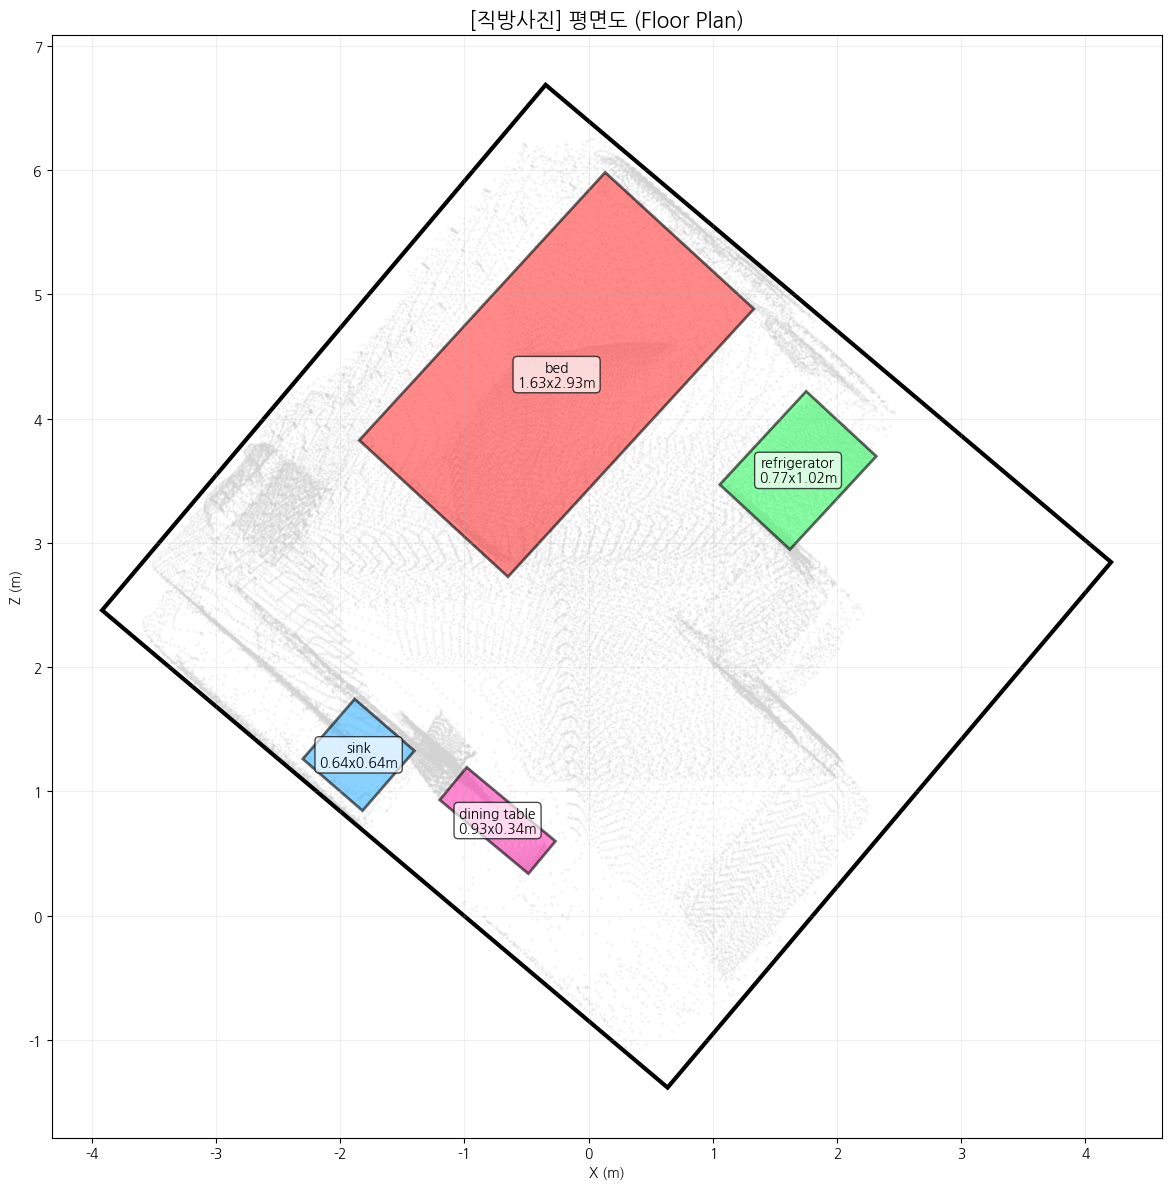

In [38]:
from matplotlib.patches import Polygon

# 스케일 적용한 m 단위 top-view 좌표
room_2d_m = room_2d * SCALE
objects_2d_m = {label: obj_2d * SCALE for label, obj_2d in objects_2d.items()}

fig, ax = plt.subplots(figsize=(12, 12))

# 방 점군 (회색)
ax.scatter(room_2d_m[::15, 0], room_2d_m[::15, 1], c="lightgray", s=1, alpha=0.2)

# 방 외곽 사각형 (minAreaRect)
room_shape = fit_shape(room_2d_m)
ax.add_patch(Polygon(room_shape["box"], closed=True, facecolor="none",
                     edgecolor="black", linewidth=3))
rw, rh = room_shape["size"]
print(f"방 외곽: {rw:.2f} x {rh:.2f} m  ({rw*rh/3.305785:.1f}평)")

# 객체별 사각형 + 라벨/크기
print("객체별 도형 크기 (m)")
for label, obj_2d in objects_2d_m.items():
    color = np.array(LABEL_COLORS.get(label, DEFAULT_COLOR)) / 255
    shape = fit_shape(obj_2d)
    ax.add_patch(Polygon(shape["box"], closed=True, facecolor=color,
                         edgecolor="black", alpha=0.6, linewidth=2))
    cx, cy = shape["center"]
    w, h = shape["size"]
    ax.text(cx, cy, f"{label}\n{w:.2f}x{h:.2f}m", ha="center", va="center",
            fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
    print(f"  {label}: {w:.2f} x {h:.2f} m")

ax.set_title(f"[{TARGET_FOLDER}] 평면도 (Floor Plan)", fontsize=15, fontweight="bold")
ax.set_xlabel("X (m)"); ax.set_ylabel("Z (m)")
ax.set_aspect("equal"); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f"/content/02_Data/{TARGET_FOLDER}_floorplan.png", dpi=150, bbox_inches="tight")
plt.show()

## 마무리: 결과가 부족할 때 체크리스트

1. **평면도가 여전히 찌그러짐** → 섹션 6의 측면도에서 바닥이 수평인지 먼저 본다.
   바닥이 비스듬하면 정렬 실패다. 바닥 후보 비율(`percentile 35`)을 조정하거나
   입력 진단(섹션 2-1)을 확인한다. 정렬만 맞으면 투영은 자동으로 바르게 나온다.
2. **입력이 근본 원인** (섹션 2-1에서 confidence 낮음 / 카메라 몰림) → 다른 사진 세트 시도.
   이건 코드로 못 고친다. 데이터의 한계이며, 포트폴리오엔 진단 수치로 솔직히 적는다.
3. **메시는 깨지는데 포인트클라우드는 괜찮음** → 섹션 7의 포인트클라우드 GLB를 메인 산출물로.
   "희소 시점에서는 점구름 표현이 더 안정적"이라고 설명하면 된다.
4. **스케일이 안 맞음** → 섹션 9의 `REFERENCE_SIZES`와 레퍼런스 가구 탐지를 점검.
   가구 기준과 천장고 fallback이 비슷하게 수렴하는지 본다.
5. **객체가 안 잡힘** → 섹션 3의 YOLO conf 임계나 `LABEL_MERGE`를 이 매물에 맞게 조정.

각 단계의 중간 산출물(png/glb)이 `/content/02_Data/`와 `/content/`에 남으니 그걸로 추적한다.

### 다른 방 사진을 넣을 때
- 섹션 1의 `TARGET_FOLDER`만 바꾸면 전체가 그대로 돈다.
- 매물 가구 구성이 다르면 섹션 9 `REFERENCE_SIZES`에 그 방에 확실히 있는 가구를 넣는다.
- 좌표 정렬(섹션 6)은 입력에 상관없이 매번 그 방의 바닥을 새로 찾아 맞추므로 별도 수정이 필요 없다.

### 포트폴리오 서사 한 줄
> 부동산 사진 몇 장에서, 공개 SOTA 모델(DUSt3R·YOLO11·SAM2)을 통합·보정해
> **실제 평수 대비 오차 X% 수준의** 측정 가능한 3D 공간을 복원하는 end-to-end 파이프라인.


## 11. 보행 가능 공간 분석 (Walkable Space)

복원된 공간에서 가구를 뺀, 사람이 실제로 다닐 수 있는 바닥 면적을 계산한다.
바닥/가구를 위에서 내려다본 점유 격자(occupancy grid)로 만들어 `바닥 - 가구`로 구한다.
격자 방식이라 비직사각형 방도 그대로 표현되고 노이즈에 안정적이다.
앞 섹션에서 만든 all_pts / objects_3d_aligned / SCALE / floor_peak 를 그대로 사용한다.


In [39]:
from matplotlib.patches import Patch
from scipy import ndimage

CELL = 0.05               # 격자 한 칸 크기 (m)
FLOOR_BAND = (-0.02, 0.08)  # 바닥 봉우리 기준 위아래 띠 (raw)
CLOSE_ITER = 2            # 바닥 구멍 메우기 강도
PERSON_CLEARANCE = 0.0   # 보행 여유 반경 (m). 0이면 단순 (바닥 - 가구)

if "floor_peak" not in globals():
    _up = all_pts[:, 1]
    _h, _e = np.histogram(_up, bins=80)
    _c = (_e[:-1] + _e[1:]) / 2
    _k = int(len(_c) * 0.35)
    floor_peak = _c[:_k][np.argmax(_h[:_k])]

cell_area = CELL * CELL

In [40]:
# 바닥 띠 점 (X-Z, 미터) + 격자 틀
up = all_pts[:, 1]
band = (up > floor_peak + FLOOR_BAND[0]) & (up < floor_peak + FLOOR_BAND[1])
floor_xz = all_pts[band][:, [0, 2]] * SCALE

bounds_src = [floor_xz] + [p[:, [0, 2]] * SCALE for p in objects_3d_aligned.values()]
allxz = np.concatenate(bounds_src, axis=0)
xmin, zmin = allxz.min(0) - CELL * 2
xmax, zmax = allxz.max(0) + CELL * 2
W = int(np.ceil((xmax - xmin) / CELL))
H = int(np.ceil((zmax - zmin) / CELL))


def rasterize(xz):
    gx = np.clip(((xz[:, 0] - xmin) / CELL).astype(int), 0, W - 1)
    gz = np.clip(((xz[:, 1] - zmin) / CELL).astype(int), 0, H - 1)
    m = np.zeros((H, W), dtype=bool)
    m[gz, gx] = True
    return m


# 바닥 점유 격자 (점 사이 구멍 메우고 가장 큰 연결 영역만)
floor_mask = rasterize(floor_xz)
floor_mask = ndimage.binary_closing(floor_mask, iterations=CLOSE_ITER)
floor_mask = ndimage.binary_fill_holes(floor_mask)
lab, ncomp = ndimage.label(floor_mask)
if ncomp > 1:
    sizes = ndimage.sum(np.ones_like(lab), lab, range(1, ncomp + 1))
    floor_mask = (lab == (int(np.argmax(sizes)) + 1))
floor_area = floor_mask.sum() * cell_area
print(f"바닥 면적: {floor_area:.2f} m^2  ({floor_area/3.305785:.1f}평)")

바닥 면적: 25.51 m^2  (7.7평)


In [41]:
# 가구 점유 격자
furn_mask = np.zeros((H, W), dtype=bool)
furn_masks = {}
for label, pts in objects_3d_aligned.items():
    fm = rasterize(pts[:, [0, 2]] * SCALE)
    fm = ndimage.binary_closing(fm, iterations=1)
    fm = ndimage.binary_fill_holes(fm)
    fm = fm & floor_mask
    furn_masks[label] = fm
    furn_mask |= fm

# 보행 가능 = 바닥 - 가구
walkable = floor_mask & ~furn_mask
if PERSON_CLEARANCE > 0:
    r = max(1, int(round(PERSON_CLEARANCE / CELL)))
    walkable = ndimage.binary_erosion(walkable, iterations=r)

furn_area = (furn_mask & floor_mask).sum() * cell_area
walk_area = walkable.sum() * cell_area
ratio = walk_area / floor_area * 100 if floor_area > 0 else 0
print(f"바닥 전체   : {floor_area:5.2f} m^2  ({floor_area/3.305785:.1f}평)")
print(f"가구 점유   : {furn_area:5.2f} m^2  ({furn_area/floor_area*100:.0f}%)")
print(f"보행 가능   : {walk_area:5.2f} m^2  ({walk_area/3.305785:.1f}평)")
print(f"공간 활용도 : 바닥의 {ratio:.0f}% 가 보행 가능")

바닥 전체   : 25.51 m^2  (7.7평)
가구 점유   :  6.21 m^2  (24%)
보행 가능   : 19.31 m^2  (5.8평)
공간 활용도 : 바닥의 76% 가 보행 가능


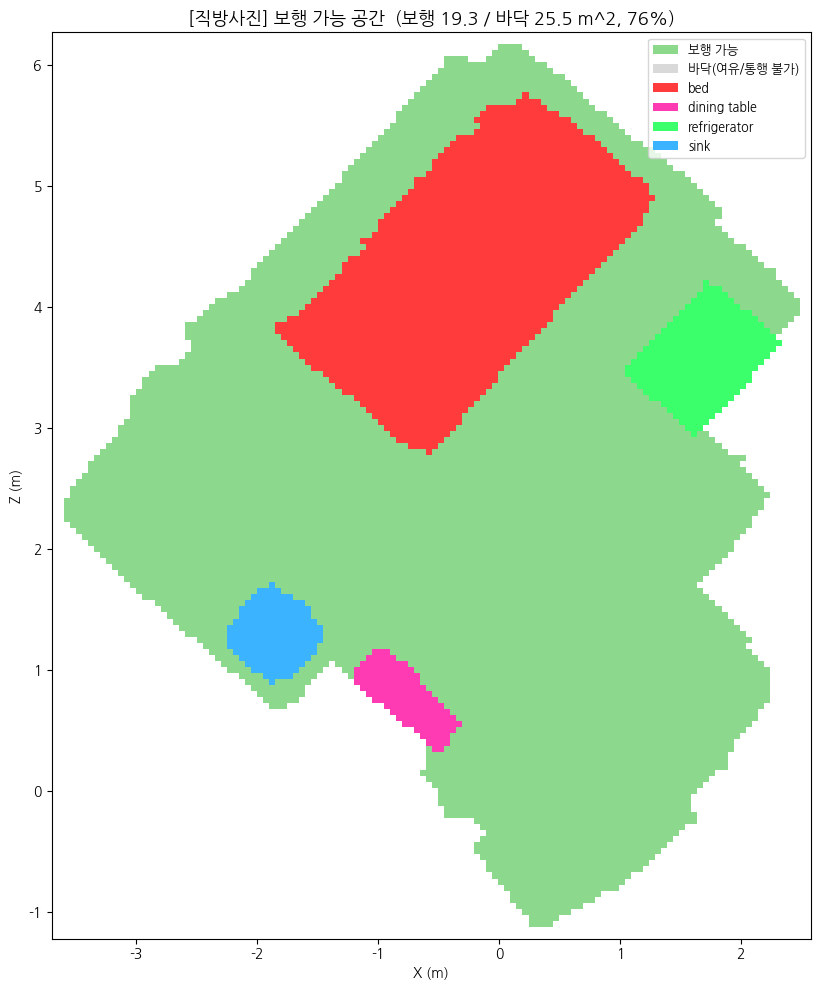

In [42]:
img = np.ones((H, W, 3))
img[floor_mask] = [0.85, 0.85, 0.85]
for label, fm in furn_masks.items():
    img[fm] = np.array(LABEL_COLORS.get(label, DEFAULT_COLOR)) / 255
img[walkable] = [0.55, 0.85, 0.55]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img, origin="lower", extent=[xmin, xmax, zmin, zmax])
ax.set_title(f"[{TARGET_FOLDER}] 보행 가능 공간  "
             f"(보행 {walk_area:.1f} / 바닥 {floor_area:.1f} m^2, {ratio:.0f}%)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("X (m)"); ax.set_ylabel("Z (m)")
ax.set_aspect("equal")

legend = [Patch(facecolor=[0.55, 0.85, 0.55], label="보행 가능"),
          Patch(facecolor=[0.85, 0.85, 0.85], label="바닥(여유/통행 불가)")]
for label, fm in furn_masks.items():
    legend.append(Patch(facecolor=np.array(LABEL_COLORS.get(label, DEFAULT_COLOR))/255, label=label))
ax.legend(handles=legend, loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(f"/content/02_Data/{TARGET_FOLDER}_walkable.png", dpi=150, bbox_inches="tight")
plt.show()